In [88]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns


In [89]:
df = pd.read_csv('ds/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [90]:
len(df)

11914

In [91]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
string_columns = list(df.dtypes[df.dtypes == 'object'].index)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [92]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


<Axes: xlabel='msrp', ylabel='Count'>

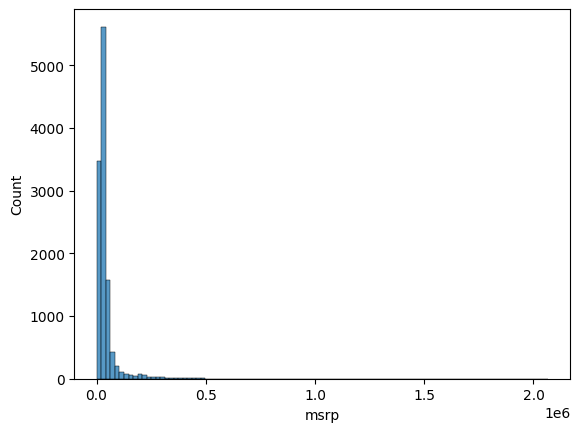

In [93]:
sns.histplot(df.msrp, bins=100)

<Axes: xlabel='msrp', ylabel='Count'>

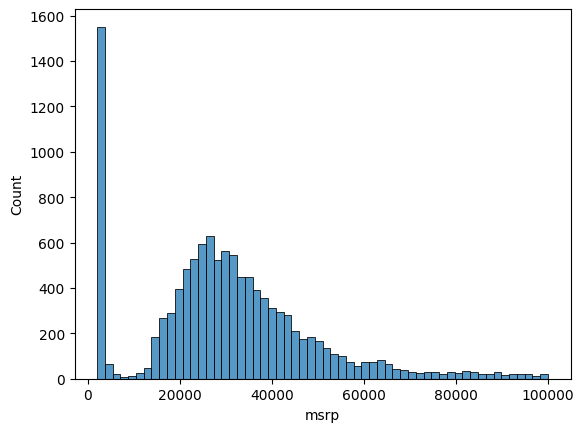

In [94]:
sns.histplot(df.msrp[df.msrp < 100000])

<Axes: xlabel='msrp', ylabel='Count'>

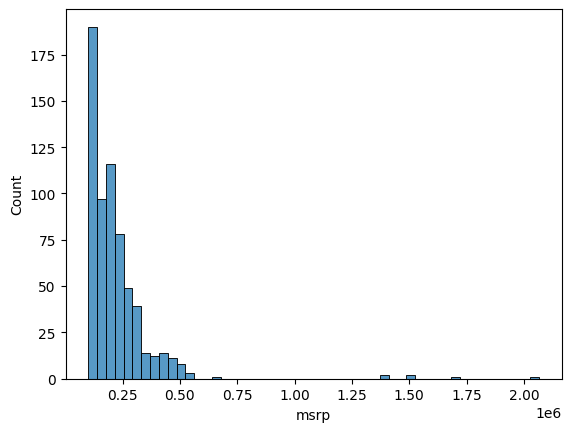

In [95]:
sns.histplot(df.msrp[df.msrp > 100000])

<Axes: xlabel='msrp', ylabel='Count'>

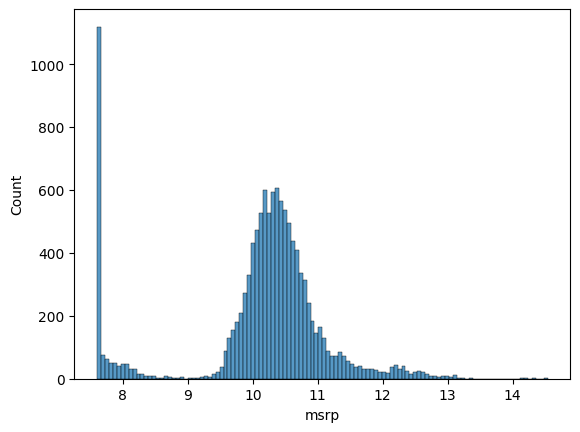

In [96]:
log_price = np.log1p(df.msrp)
sns.histplot(log_price)

In [97]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [98]:
n = len(df)
print(n)

11914


In [99]:
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = int(0.6 * n)
print(n_val, n_test, n_train)

2382 2382 7148


In [100]:
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [101]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [102]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [103]:
#Линейная регрессия на простом примере
w0 = 7.17
# [w1 w2 w3 ]
w = [0.01, 0.04, 0.002]
n = 3

def linear_regression(xi):
    w = [0.01, 0.04, 0.002]
    result = w0
    for j in range(3):
        result = result + xi[j] * w[j]
    return result

x = (453, 11, 86)
y = linear_regression(x)
print(y)
np.expm1(y)

12.312


np.float64(222347.2221101062)

In [104]:
#Скалярное произведение
def dot(xi, w):
    n = len(w)
    result = 0.0
    for i in range(n):
        result = result + xi[i] * w[i]
    return result

In [105]:
#Еще упрощаем линейную регрессию
def linear_regression(xi):
    return w0 + dot(xi, w)

In [106]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [107]:
#Выбираем наиболее подходящие данные
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
df_num = df_train[base]
df_num.isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [108]:
df_num = df_num.fillna(0)
df_num.isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [109]:
#Преобразуем в массив
X_train = df_num.values

In [110]:
w_0, w = train_linear_regression(X_train, y_train)

In [111]:
y_pred = w_0 + X_train.dot(w)

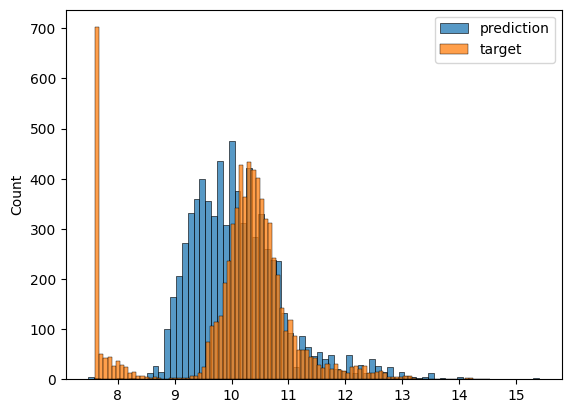

In [113]:
sns.histplot(y_pred, label = 'prediction')
sns.histplot(y_train, label = 'target')
plt.legend()